In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
## import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
## load dataset

In [4]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
## first five record

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.shape

(200, 5)

In [ ]:
## information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
## che ck for null value

In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df = df.drop("CustomerID", axis = 1)

In [42]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,4
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,2
4,1,31,17,40,4


In [ ]:
## convert Gender to numeric

In [16]:
df["Gender"] = df["Gender"].map({
    "Male" : 0,
    "Female" : 1
})

In [31]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,4
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,2
4,1,31,17,40,4


In [ ]:
## Age distribution

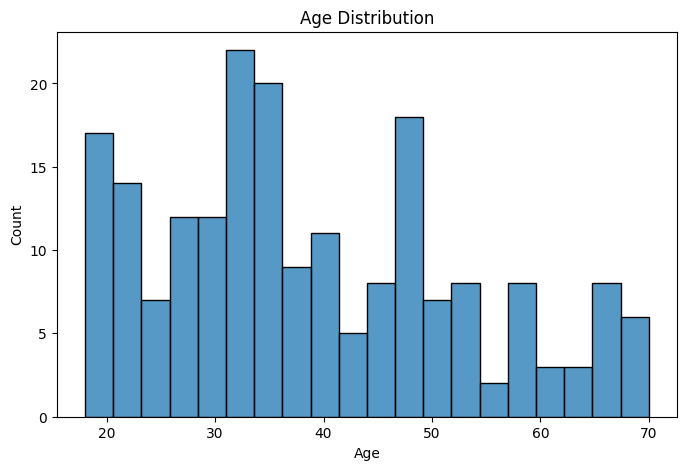

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

In [ ]:
## Annual income distrtibution

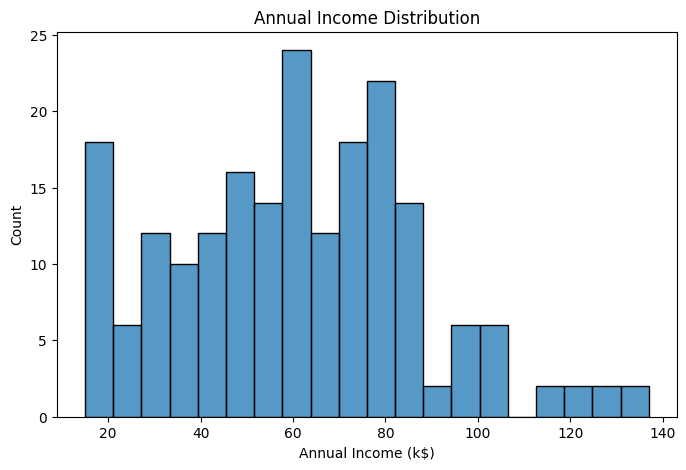

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

plt.show()

In [ ]:
## spending score distribution

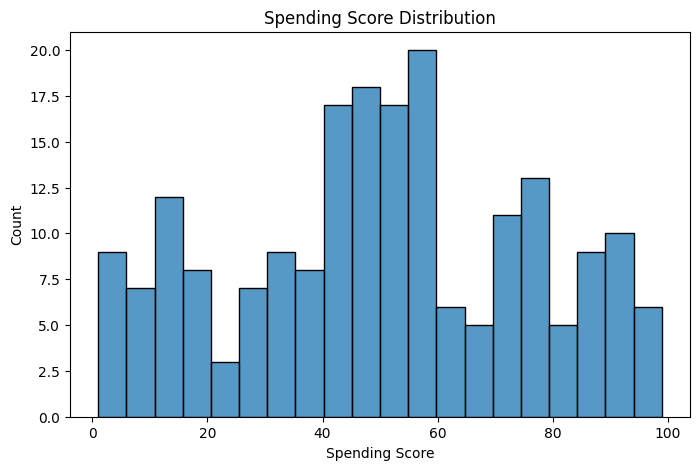

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.show()

In [ ]:
## Income vs spending score distribution

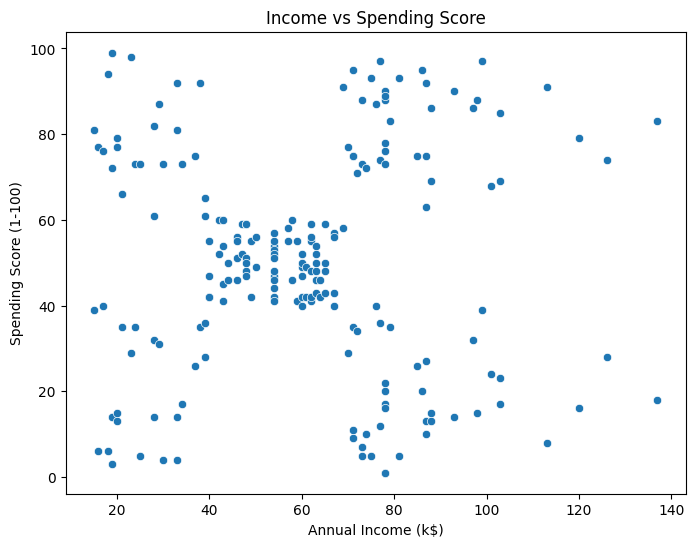

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"]
)

plt.title("Income vs Spending Score")

plt.show()

In [ ]:
## Feature selection

In [21]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
## Feature scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


In [ ]:
## Elbow method

In [24]:
wcss = []

In [25]:
for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

In [ ]:
## Elbow curve

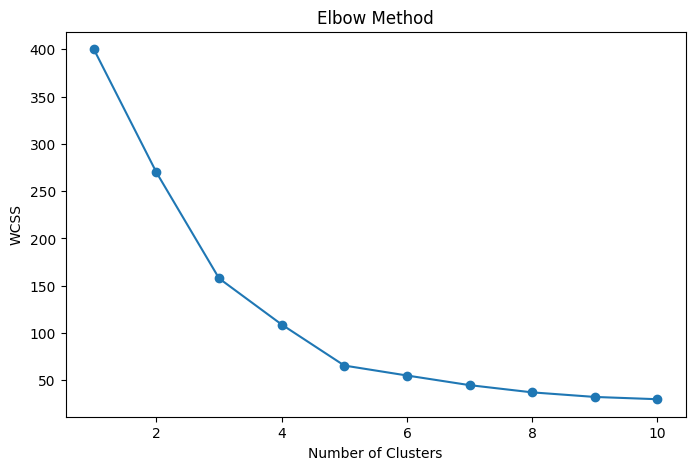

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [ ]:
## Apply k-meqans clustering

In [27]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [28]:
df["Cluster"] = clusters

In [30]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,4
1,0,21,15,81,2
2,1,20,16,6,4
3,1,23,16,77,2
4,1,31,17,40,4


In [ ]:
## customer segmentation visualization

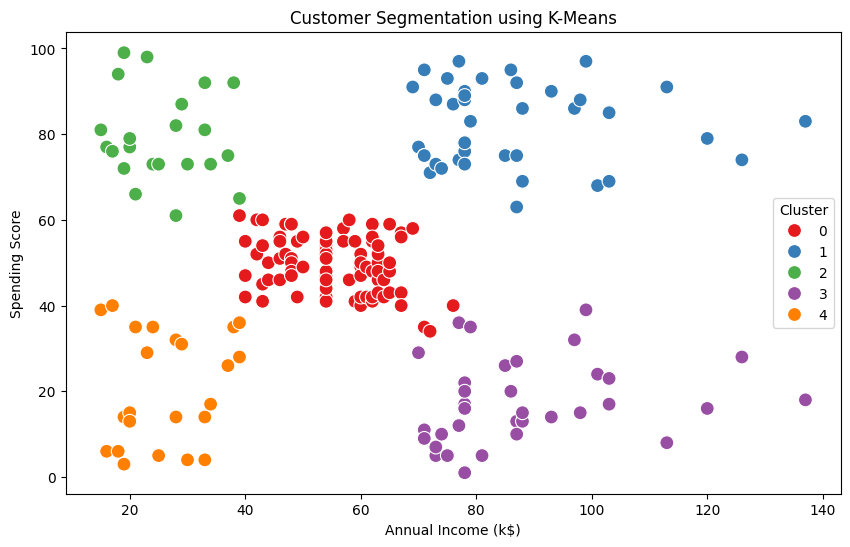

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

In [33]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

print(centers)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [45]:
cluster_summary = df.groupby("Cluster").mean().round()
print(cluster_summary)

         Gender   Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                          
0           1.0  43.0                55.0                    50.0
1           1.0  33.0                87.0                    82.0
2           1.0  25.0                26.0                    79.0
3           0.0  41.0                88.0                    17.0
4           1.0  45.0                26.0                    21.0
